# Three Baseline Classifiers on full images
This notebook trains the first three **full-image + metadata** classifiers:

1. **Sagittal T2/STIR** → Spinal Canal Stenosis  
2. **Sagittal T1** → Neural Foraminal Narrowing  
3. **Axial T2** → Subarticular Stenosis  

The input format is corrected for MRI:
- DICOM grayscale is loaded directly from `img_path`.
- Intensities are clipped using percentiles and normalized to `[0, 1]`.
- The grayscale image is repeated into **3 identical channels** for ImageNet-compatible CNNs.
- Mean and standard deviation are computed from the **training data only**, not reused from another dataset.
- ResNet34 can be trained either with ImageNet-pretrained weights or from scratch.

## 1. Imports

In [1]:
# IMPORTS
import os
import re
import copy
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
import pydicom
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix,
    classification_report,
    log_loss,
)

from tqdm.auto import tqdm

## 2. Reproducibility and configuration

In [2]:
# SET SEED FOR REPRODUCIBILITY
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)

In [3]:
# ----------------------------
# CONFIG
# ----------------------------
import os

ROOT = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification")
DATA_ROOT = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data")
PROJECT_ROOT = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Classification-baseline")
DATA_CSV = DATA_ROOT / "data-rsna2024" / "data_merged.csv"
os.chdir(ROOT)

# Output folder for trained models and results.
MODEL_ROOT_DIR = Path("models")
RUN_NAME = "models_baseline_three_class_medical"

OUTPUT_DIR = MODEL_ROOT_DIR / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PRETRAINED = False
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 8
PIN_MEMORY = True
PERSISTENT_WORKERS = NUM_WORKERS > 0
PREFETCH_FACTOR = 2
GRAD_CLIP_MAX_NORM = 1.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print("Project root:", PROJECT_ROOT)
print("Data CSV:", DATA_CSV)
print("Output dir:", OUTPUT_DIR)


Using device: cuda
Project root: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Classification-baseline
Data CSV: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data/data-rsna2024/data_merged.csv
Output dir: models/models_baseline_three_class_medical


## 3. Load and prepare dataframe

This section creates:

- `base_condition`: condition without left/right prefix
- `side`: `center`, `left`, or `right`
- `target`: severity encoded as `0`, `1`, `2`

For the first full-image classifiers, coordinates `x` and `y` are not used.

In [4]:
# LABEL DEFINITIONS
data_merged = pd.read_csv(DATA_CSV)

SEVERITY_MAP = {
    "Normal/Mild": 0,
    "Moderate": 1,
    "Severe": 2,
}

TARGET_NAMES = ["Normal/Mild", "Moderate", "Severe"]

LEVELS = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]

SIDE_TO_ID = {
    "center": 0,
    "left": 1,
    "right": 2,
}

SERIES_TO_ID = {
    "Sagittal T2/STIR": 0,
    "Sagittal T1": 1,
    "Axial T2": 2,
}

LEVEL_TO_ID = {level: idx for idx, level in enumerate(LEVELS)}


def extract_side(condition):
    condition = str(condition).lower()

    if condition.startswith("left"):
        return "left"
    elif condition.startswith("right"):
        return "right"
    else:
        return "center"


def extract_base_condition(condition):
    condition = str(condition)
    return (
        condition
        .replace("Left ", "")
        .replace("Right ", "")
    )

data_merged["side"] = data_merged["condition"].apply(extract_side)
data_merged["base_condition"] = data_merged["condition"].apply(extract_base_condition)
data_merged["target"] = data_merged["severity"].map(SEVERITY_MAP)


data_merged = data_merged.dropna(subset=[
    "study_id",
    "img_path",
    "target",
    "level",
    "side",
    "series_description",
]).copy()

data_merged["target"] = data_merged["target"].astype(int)
print(data_merged["base_condition"].value_counts())
print("==========================")
print(data_merged["series_description"].value_counts())
#display(data_merged.head())

base_condition
Neural Foraminal Narrowing    19689
Subarticular Stenosis         19215
Spinal Canal Stenosis          9753
Name: count, dtype: int64
series_description
Sagittal T1         19694
Axial T2            19215
Sagittal T2/STIR     9748
Name: count, dtype: int64


## 4. Study-level train/validation/test split
Split is created by `study_id`, which prevents patient/study leakage.

In [5]:
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42

# First split: train vs temporary validation + test
gss1 = GroupShuffleSplit(
    n_splits=1,
    train_size=TRAIN_SIZE,
    random_state=RANDOM_STATE,
)

train_idx, temp_idx = next(
    gss1.split(
        data_merged,
        groups=data_merged["study_id"],
    )
)

train_df = data_merged.iloc[train_idx].copy()
temp_df = data_merged.iloc[temp_idx].copy()

# Second split: validation vs test from the temporary set
val_relative_size = VAL_SIZE / (VAL_SIZE + TEST_SIZE)

gss2 = GroupShuffleSplit(
    n_splits=1,
    train_size=val_relative_size,
    random_state=RANDOM_STATE,
)

val_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df["study_id"],
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Rows:")
print("train:", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)

print("\nUnique studies:")
print("train:", train_df["study_id"].nunique())
print("val:  ", val_df["study_id"].nunique())
print("test: ", test_df["study_id"].nunique())

Rows:
train: (34045, 14)
val:   (7289, 14)
test:  (7323, 14)

Unique studies:
train: 1381
val:   296
test:  297


In [6]:
# Cell 1: prepare merged dataframe
plot_df = pd.concat(
    [
        train_df[["condition", "base_condition", "severity"]].assign(split="train"),
        val_df[["condition", "base_condition", "severity"]].assign(split="val"),
        test_df[["condition", "base_condition", "severity"]].assign(split="test"),
    ],
    ignore_index=True,
)

plot_df["condition_plot"] = plot_df["base_condition"]

plot_df.loc[
    plot_df["condition"].str.contains("Left Neural Foraminal Narrowing", na=False),
    "condition_plot"
] = "Left Neural Foraminal Narrowing"

plot_df.loc[
    plot_df["condition"].str.contains("Right Neural Foraminal Narrowing", na=False),
    "condition_plot"
] = "Right Neural Foraminal Narrowing"

severity_order = ["Normal/Mild", "Moderate", "Severe"]
split_order = ["train", "val", "test"]

plot_df["severity"] = pd.Categorical(plot_df["severity"], categories=severity_order, ordered=True)
plot_df["split"] = pd.Categorical(plot_df["split"], categories=split_order, ordered=True)

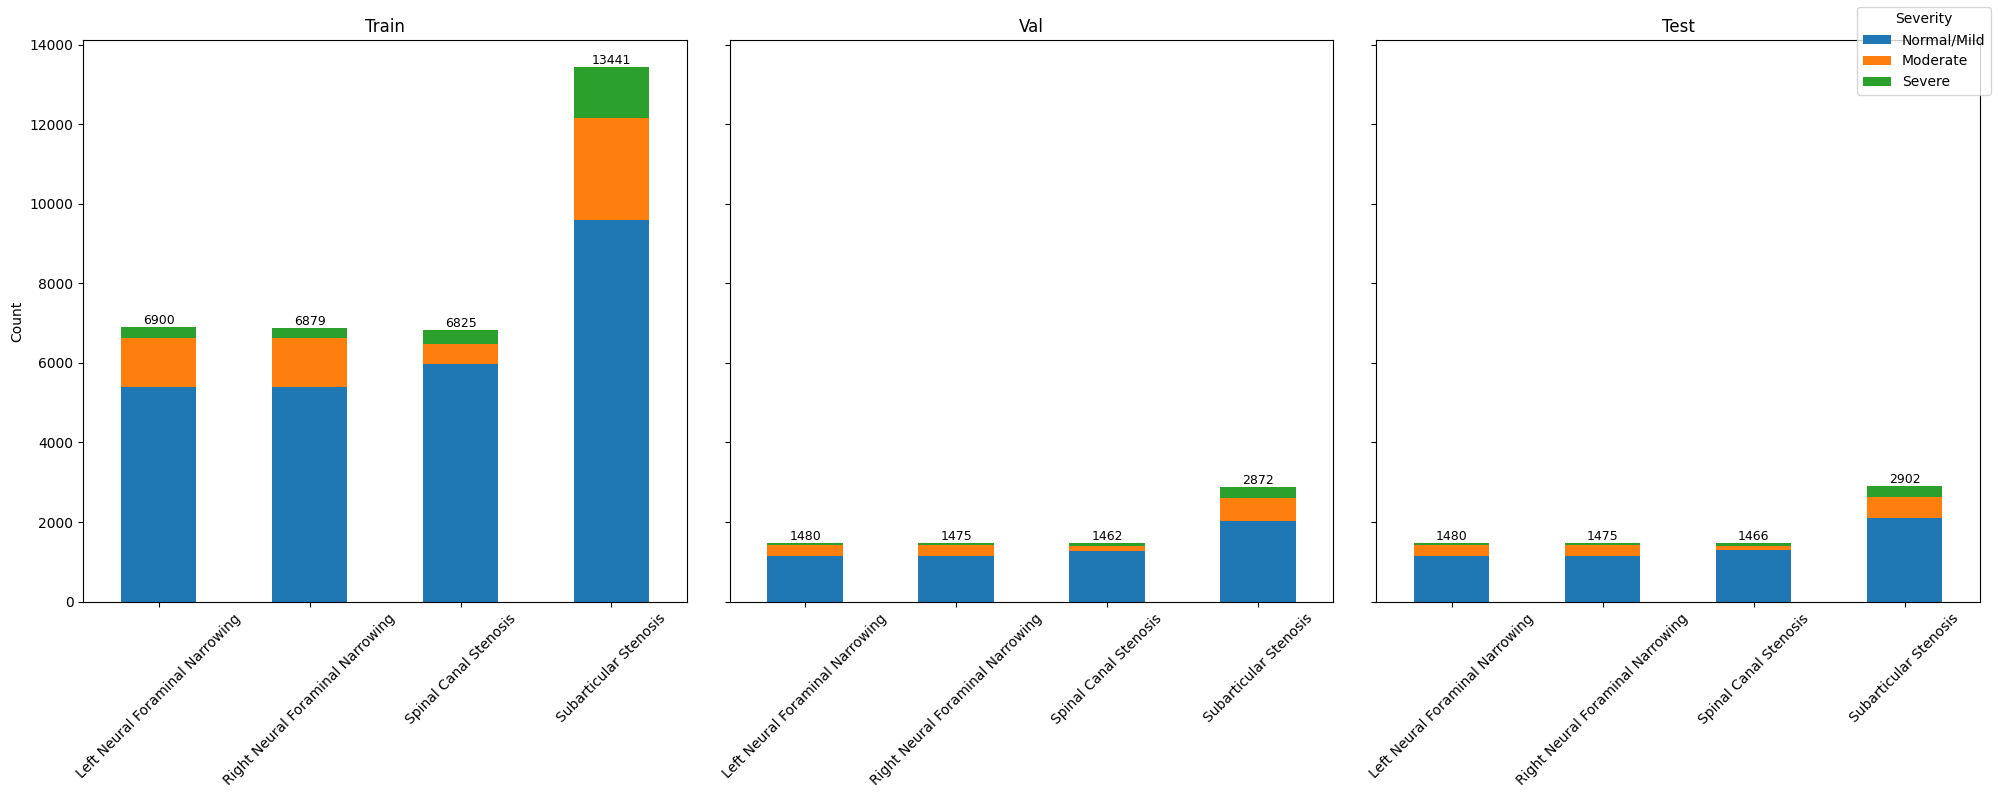

In [7]:
# Cell 2: side-by-side stacked bar charts with total counts

import matplotlib.pyplot as plt

condition_order = sorted(plot_df["condition_plot"].dropna().unique())

fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)

for ax, split in zip(axes, split_order):
    split_counts = pd.crosstab(
        plot_df.loc[plot_df["split"] == split, "condition_plot"],
        plot_df.loc[plot_df["split"] == split, "severity"]
    ).reindex(index=condition_order, columns=severity_order, fill_value=0)

    split_counts.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        legend=False
    )

    totals = split_counts.sum(axis=1)

    for i, total in enumerate(totals):
        ax.text(
            i,
            total,
            str(int(total)),
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(f"{split.capitalize()}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Count")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Severity", loc="upper right")

plt.tight_layout()
plt.show()

## 5. Define the three classifiers

Each model is trained on the matching sequence and condition.

In [8]:
MODEL_CONFIGS = {
    "spinal_canal_stenosis": {
        "base_condition": "Spinal Canal Stenosis",
        "series_description": "Sagittal T2/STIR",
    },
    "neural_foraminal_narrowing": {
        "base_condition": "Neural Foraminal Narrowing",
        "series_description": "Sagittal T1",
    },
    "subarticular_stenosis": {
        "base_condition": "Subarticular Stenosis",
        "series_description": "Axial T2",
    },
}


def make_model_df(df, base_condition, series_description):
    out = df[
        (df["base_condition"] == base_condition) &
        (df["series_description"] == series_description)
    ].copy()

    out = out.dropna(subset=[
        "img_path",
        "target",
        "level",
        "side",
        "series_description",
    ])

    return out.reset_index(drop=True)


model_dfs = {}

for model_name, cfg in MODEL_CONFIGS.items():
    model_dfs[model_name] = {
        "train": make_model_df(train_df, cfg["base_condition"], cfg["series_description"]),
        "val": make_model_df(val_df, cfg["base_condition"], cfg["series_description"]),
        "test": make_model_df(test_df, cfg["base_condition"], cfg["series_description"]),
    }

for model_name, parts in model_dfs.items():
    print("\n", model_name)
    for split_name, split_df in parts.items():
        print(f"{split_name:5s}: {len(split_df):6d} rows | {split_df['study_id'].nunique():4d} studies")
        print(split_df["target"].value_counts().sort_index().rename(index=dict(enumerate(TARGET_NAMES))))


 spinal_canal_stenosis
train:   6820 rows | 1380 studies
target
Normal/Mild    5964
Moderate        513
Severe          343
Name: count, dtype: int64
val  :   1462 rows |  296 studies
target
Normal/Mild    1282
Moderate        117
Severe           63
Name: count, dtype: int64
test :   1466 rows |  297 studies
target
Normal/Mild    1303
Moderate        101
Severe           62
Name: count, dtype: int64

 neural_foraminal_narrowing
train:  13779 rows | 1380 studies
target
Normal/Mild    10800
Moderate        2462
Severe           517
Name: count, dtype: int64
val  :   2955 rows |  296 studies
target
Normal/Mild    2280
Moderate        538
Severe          137
Name: count, dtype: int64
test :   2955 rows |  296 studies
target
Normal/Mild    2275
Moderate        559
Severe          121
Name: count, dtype: int64

 subarticular_stenosis
train:  13441 rows | 1381 studies
target
Normal/Mild    9601
Moderate       2549
Severe         1291
Name: count, dtype: int64
val  :   2872 rows |  296 studi

## 6. Create dataset

The default input is:

```text
DICOM grayscale → percentile clipping → [0, 1] normalization → PIL grayscale
```

Then transforms convert it to a 3-channel tensor by repeating grayscale values.

This dataset returns:

```text
image tensor, metadata dictionary, target label
```

For the first three classifiers, coordinates are intentionally not used.

In [9]:
def read_dicom_array(path, clip_percentiles=(1, 99)):
    """Read one DICOM image and return a normalized float32 grayscale array in [0, 1]."""
    ds = pydicom.dcmread(path)

    img = ds.pixel_array.astype(np.float32)

    # Correct display inversion for MONOCHROME1.
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    # Robust clipping reduces the influence of extreme values.
    low, high = np.percentile(img, clip_percentiles)
    if high > low:
        img = np.clip(img, low, high)

    # Normalize to [0, 1].
    img = img - img.min()
    denom = img.max()
    if denom > 0:
        img = img / denom

    return img.astype(np.float32)

def read_dicom_as_pil_grayscale(path):
    """Read DICOM and convert to PIL grayscale image."""
    img = read_dicom_array(path)
    img_uint8 = (img * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(img_uint8).convert("L")

In [10]:
class LumbarMetadataClassificationDataset(Dataset):
    def __init__(
        self,
        df,
        transform=None,
        level_to_id=None,
        side_to_id=None,
        series_to_id=None,
    ):
        self.df = df.reset_index(drop=True)
        self.transform = transform

        self.level_to_id = level_to_id if level_to_id is not None else LEVEL_TO_ID
        self.side_to_id = side_to_id if side_to_id is not None else SIDE_TO_ID
        self.series_to_id = series_to_id if series_to_id is not None else SERIES_TO_ID

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = read_dicom_as_pil_grayscale(row["img_path"])

        if self.transform is not None:
            image = self.transform(image)

        metadata = {
            "level": torch.tensor(self.level_to_id[row["level"]], dtype=torch.long),
            "side": torch.tensor(self.side_to_id[row["side"]], dtype=torch.long),
            "series": torch.tensor(self.series_to_id[row["series_description"]], dtype=torch.long),
        }

        target = torch.tensor(int(row["target"]), dtype=torch.long)

        return image, metadata, target

## 8. Compute mean and standard deviation from training data only

This replaces the old mean/std values that were computed on another dataset.

Default: compute one global mean/std from all three model training subsets.  
This keeps preprocessing consistent across the three classifiers.

In [11]:
# Transform used only for mean/std calculation.
# No normalization here.
mean_std_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])


@torch.no_grad()
def compute_mean_std(df, batch_size=32, num_workers=2):
    dataset = LumbarMetadataClassificationDataset(
        df,
        transform=mean_std_transform,
    )

    loader_kwargs = {
        "dataset": dataset,
        "batch_size": batch_size,
        "shuffle": False,
        "num_workers": num_workers,
        "pin_memory": PIN_MEMORY,
        "persistent_workers": (num_workers > 0),
    }
    if num_workers > 0:
        loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

    loader = DataLoader(**loader_kwargs)

    channel_sum = torch.zeros(3)
    channel_sum_sq = torch.zeros(3)
    num_pixels = 0

    for images, metadata, targets in tqdm(loader, desc="Computing mean/std"):
        # images shape: [B, C, H, W]
        images = images.float()
        b, c, h, w = images.shape

        channel_sum += images.sum(dim=(0, 2, 3))
        channel_sum_sq += (images ** 2).sum(dim=(0, 2, 3))
        num_pixels += b * h * w

    mean = channel_sum / num_pixels
    variance = channel_sum_sq / num_pixels - mean ** 2
    std = torch.sqrt(torch.clamp(variance, min=1e-8))

    return mean.tolist(), std.tolist()


# Combine only TRAINING rows from the three classifiers.
norm_train_df = pd.concat(
    [model_dfs[name]["train"] for name in MODEL_CONFIGS.keys()],
    axis=0,
    ignore_index=True,
).drop_duplicates(subset=["img_path", "level", "side", "base_condition"])

print("Rows used for mean/std:", len(norm_train_df))

mean, std = compute_mean_std(
    norm_train_df,
    batch_size=32,
    num_workers=NUM_WORKERS,
)

print("Computed mean:", mean)
print("Computed std: ", std)

# Save for reproducibility.
pd.DataFrame({"mean": mean, "std": std}).to_csv(OUTPUT_DIR / "computed_train_mean_std.csv", index=False)

Rows used for mean/std: 34040


Computing mean/std:   0%|          | 0/1064 [00:00<?, ?it/s]

Computed mean: [0.22406505048274994, 0.22406505048274994, 0.22406505048274994]
Computed std:  [0.25239378213882446, 0.25239378213882446, 0.25239378213882446]


## 9. Transforms

The image remains grayscale MRI information, but is repeated into three channels for ResNet34 compatibility.

In [12]:
# TRANSFORMS
# Grayscale(num_output_channels=3) creates [gray, gray, gray].

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomRotation(degrees=5),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.02, 0.02),
        scale=(0.95, 1.05),
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

## 10. Visual sanity check

This confirms that the dataset loads DICOMs correctly and that labels/metadata are valid.

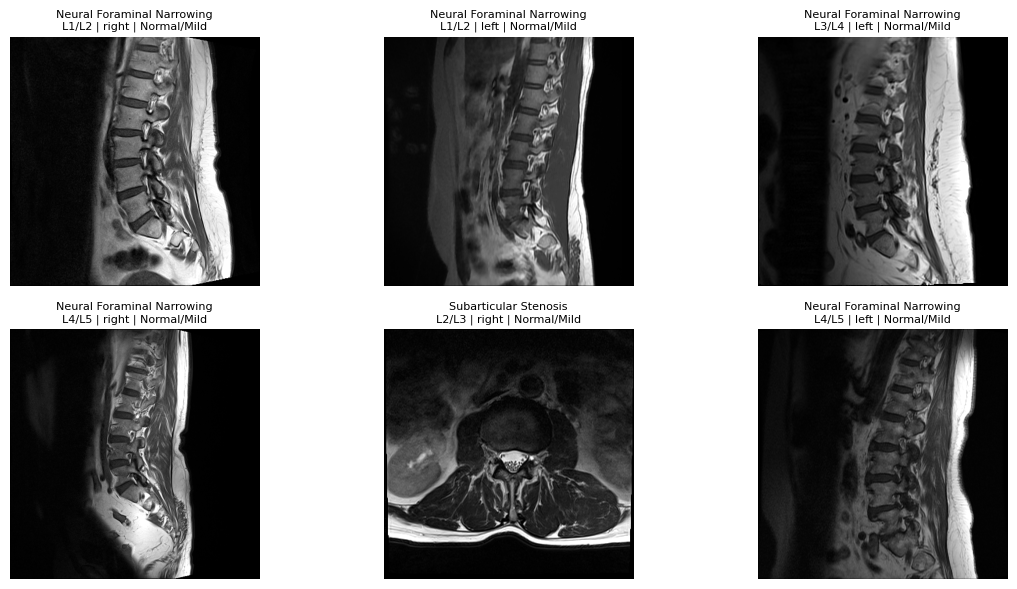

In [13]:
# VISUAL SANITY CHECK BEFORE NORMALIZATION
sample_df = norm_train_df.sample(min(6, len(norm_train_df)), random_state=42)

plt.figure(figsize=(12, 6))

for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
    img = read_dicom_array(row["img_path"])

    plt.subplot(2, 3, i)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(
        f"{row['base_condition']}\n"
        f"{row['level']} | {row['side']} | {row['severity']}",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

## 11. Image + metadata ResNet34 model

The CNN extracts image features.  
Metadata embeddings for `level`, `side`, and `series_description` are concatenated with image features before classification.

In [14]:
class ResNet34MetadataClassifier(nn.Module):
    def __init__(
        self,
        n_levels=5,
        n_sides=3,
        n_series=3,
        n_classes=3,
        pretrained=True,
        level_emb_dim=8,
        side_emb_dim=4,
        series_emb_dim=4,
        hidden_dim=256,
        dropout=0.3,
    ):
        super().__init__()

        if pretrained:
            weights = models.ResNet34_Weights.IMAGENET1K_V1
        else:
            weights = None

        self.backbone = models.resnet34(weights=weights)

        image_feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.level_emb = nn.Embedding(n_levels, level_emb_dim)
        self.side_emb = nn.Embedding(n_sides, side_emb_dim)
        self.series_emb = nn.Embedding(n_series, series_emb_dim)

        metadata_dim = level_emb_dim + side_emb_dim + series_emb_dim

        self.classifier = nn.Sequential(
            nn.Linear(image_feature_dim + metadata_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, images, metadata):
        image_features = self.backbone(images)

        level_features = self.level_emb(metadata["level"])
        side_features = self.side_emb(metadata["side"])
        series_features = self.series_emb(metadata["series"])

        metadata_features = torch.cat(
            [level_features, side_features, series_features],
            dim=1,
        )

        features = torch.cat(
            [image_features, metadata_features],
            dim=1,
        )

        logits = self.classifier(features)
        return logits

## 12. Loss, loaders, training, and evaluation utilities

In [15]:
def move_metadata_to_device(metadata, device):
    return {
        key: value.to(device, non_blocking=True)
        for key, value in metadata.items()
    }


def make_class_weighted_loss(train_df, device):
    # Robust class weights.
    # If a class is absent in a split, its weight is set to 0.
    counts = np.bincount(train_df["target"].values, minlength=3).astype(np.float32)
    total = counts.sum()

    weights = np.zeros(3, dtype=np.float32)
    for cls in range(3):
        if counts[cls] > 0:
            weights[cls] = total / (3.0 * counts[cls])
        else:
            weights[cls] = 0.0

    print("Class counts:", dict(zip(TARGET_NAMES, counts.astype(int))))
    print("Class weights:", dict(zip(TARGET_NAMES, weights.round(4))))

    weights = torch.tensor(weights, dtype=torch.float32).to(device)
    return nn.CrossEntropyLoss(weight=weights)


def _make_dataloader(dataset, batch_size, shuffle=False, drop_last=False):
    loader_kwargs = {
        "dataset": dataset,
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "persistent_workers": (NUM_WORKERS > 0),
        "drop_last": drop_last,
    }

    if NUM_WORKERS > 0:
        loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

    return DataLoader(**loader_kwargs)


def make_loaders(train_part, val_part, batch_size=BATCH_SIZE):
    train_dataset = LumbarMetadataClassificationDataset(
        train_part,
        transform=train_transform,
    )

    val_dataset = LumbarMetadataClassificationDataset(
        val_part,
        transform=val_transform,
    )

    train_loader = _make_dataloader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
    )

    val_loader = _make_dataloader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )

    return train_loader, val_loader


def make_test_loader(test_part, batch_size=BATCH_SIZE):
    test_dataset = LumbarMetadataClassificationDataset(
        test_part,
        transform=val_transform,
    )

    test_loader = _make_dataloader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )

    return test_loader


In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    n_seen = 0
    all_preds = []
    all_labels = []

    for images, metadata, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        metadata = move_metadata_to_device(metadata, device)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images, metadata)
        loss = criterion(logits, labels)

        loss.backward()
        if GRAD_CLIP_MAX_NORM is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_MAX_NORM)
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_seen += batch_size

        preds = logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / max(n_seen, 1)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return epoch_loss, epoch_acc, epoch_bal_acc, epoch_f1


@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    n_seen = 0
    all_preds = []
    all_labels = []
    all_probs = []

    for images, metadata, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        metadata = move_metadata_to_device(metadata, device)
        labels = labels.to(device, non_blocking=True)

        logits = model(images, metadata)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_seen += batch_size

        all_probs.extend(probs.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    all_probs = np.asarray(all_probs)
    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)

    epoch_loss = running_loss / max(n_seen, 1)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    severe_recall = recall_score(
        all_labels,
        all_preds,
        labels=[2],
        average="macro",
        zero_division=0,
    )

    try:
        epoch_logloss = log_loss(all_labels, all_probs, labels=[0, 1, 2])
    except ValueError:
        epoch_logloss = np.nan

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "balanced_accuracy": epoch_bal_acc,
        "macro_f1": epoch_f1,
        "severe_recall": severe_recall,
        "log_loss": epoch_logloss,
        "y_true": all_labels,
        "y_pred": all_preds,
        "y_prob": all_probs,
    }


In [17]:
def fit_model(
    model_name,
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs=EPOCHS,
):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_f1 = -np.inf

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_balanced_accuracy": [],
        "train_macro_f1": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_balanced_accuracy": [],
        "val_macro_f1": [],
        "val_severe_recall": [],
        "val_log_loss": [],
    }

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")

        train_loss, train_acc, train_bal_acc, train_f1 = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
        )

        val_metrics = evaluate_one_epoch(
            model,
            val_loader,
            criterion,
            device,
        )

        if scheduler is not None:
            scheduler.step(val_metrics["loss"])

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["train_balanced_accuracy"].append(train_bal_acc)
        history["train_macro_f1"].append(train_f1)

        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_balanced_accuracy"].append(val_metrics["balanced_accuracy"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["val_severe_recall"].append(val_metrics["severe_recall"])
        history["val_log_loss"].append(val_metrics["log_loss"])

        print(
            f"Train loss: {train_loss:.4f} | "
            f"Train acc: {train_acc:.4f} | "
            f"Train bal acc: {train_bal_acc:.4f} | "
            f"Train macro F1: {train_f1:.4f}"
        )

        print(
            f"Val loss: {val_metrics['loss']:.4f} | "
            f"Val acc: {val_metrics['accuracy']:.4f} | "
            f"Val bal acc: {val_metrics['balanced_accuracy']:.4f} | "
            f"Val macro F1: {val_metrics['macro_f1']:.4f} | "
            f"Val severe recall: {val_metrics['severe_recall']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            best_model_wts = copy.deepcopy(model.state_dict())

            save_path = OUTPUT_DIR / f"{model_name}_best.pt"
            torch.save(best_model_wts, save_path)
            print(f"Saved best model: {save_path}")

    model.load_state_dict(best_model_wts)

    history_df = pd.DataFrame(history)
    history_df.insert(0, "epoch", range(1, len(history_df) + 1))
    history_df.to_csv(OUTPUT_DIR / f"{model_name}_history.csv", index=False)

    return model, history_df

## 13. Plot helpers

In [18]:
def plot_history(history_df, title="Training history"):
    epochs = history_df["epoch"]

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history_df["train_loss"], label="train")
    plt.plot(epochs, history_df["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history_df["train_balanced_accuracy"], label="train")
    plt.plot(epochs, history_df["val_balanced_accuracy"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Balanced accuracy")
    plt.title("Balanced accuracy")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history_df["train_macro_f1"], label="train")
    plt.plot(epochs, history_df["val_macro_f1"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")
    plt.title("Macro F1")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_confusion_and_report(y_true, y_pred, class_names=TARGET_NAMES, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

    print(classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=class_names,
        zero_division=0,
    ))

## 14. Train the three classifiers

This trains:

- `spinal_canal_stenosis`
- `neural_foraminal_narrowing`
- `subarticular_stenosis`


Training model: spinal_canal_stenosis
Class counts: {'Normal/Mild': np.int64(5964), 'Moderate': np.int64(513), 'Severe': np.int64(343)}
Class weights: {'Normal/Mild': np.float32(0.3812), 'Moderate': np.float32(4.4314), 'Severe': np.float32(6.6278)}

Epoch 1/10


  0%|          | 0/426 [00:00<?, ?it/s]

  0%|          | 0/92 [00:00<?, ?it/s]

Train loss: 1.0521 | Train acc: 0.6944 | Train bal acc: 0.4494 | Train macro F1: 0.3976
Val loss: 0.8777 | Val acc: 0.6389 | Val bal acc: 0.4784 | Val macro F1: 0.3467 | Val severe recall: 0.0000
Saved best model: models/models_baseline_three_class_medical/spinal_canal_stenosis_best.pt

Epoch 2/10


  0%|          | 0/426 [00:00<?, ?it/s]

...

  0%|          | 0/92 [00:00<?, ?it/s]

Train loss: 0.7527 | Train acc: 0.8187 | Train bal acc: 0.6436 | Train macro F1: 0.5680
Val loss: 0.7185 | Val acc: 0.8269 | Val bal acc: 0.5825 | Val macro F1: 0.5439 | Val severe recall: 0.3968
Saved best model: models/models_baseline_three_class_medical/spinal_canal_stenosis_best.pt

Epoch 10/10


  0%|          | 0/426 [00:00<?, ?it/s]

  0%|          | 0/92 [00:00<?, ?it/s]

Train loss: 0.7251 | Train acc: 0.8207 | Train bal acc: 0.6513 | Train macro F1: 0.5743
Val loss: 0.6936 | Val acc: 0.8181 | Val bal acc: 0.6021 | Val macro F1: 0.5520 | Val severe recall: 0.4286
Saved best model: models/models_baseline_three_class_medical/spinal_canal_stenosis_best.pt


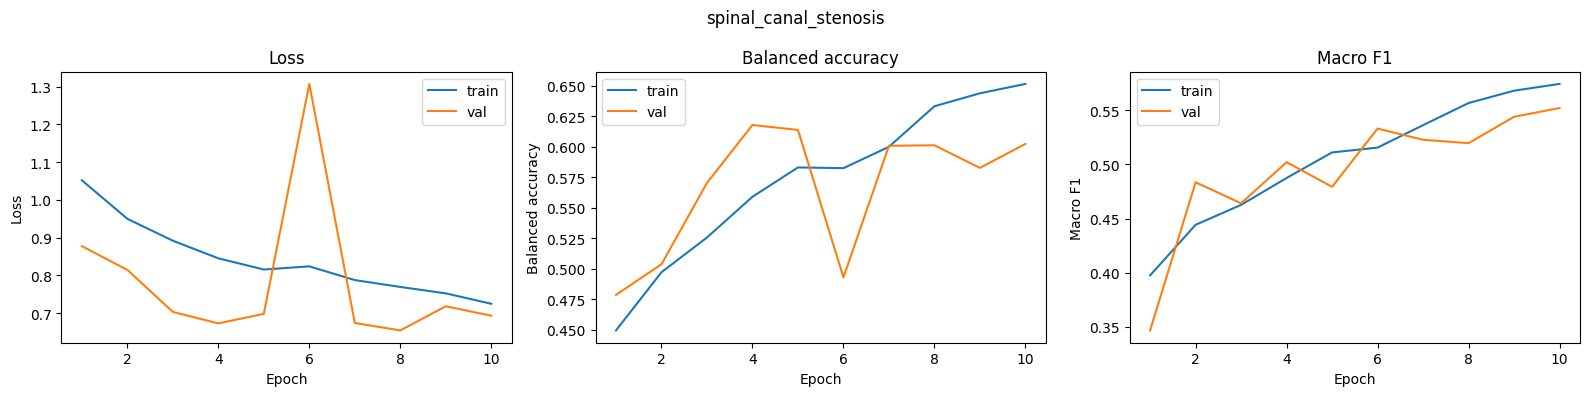


Training model: neural_foraminal_narrowing
Class counts: {'Normal/Mild': np.int64(10800), 'Moderate': np.int64(2462), 'Severe': np.int64(517)}
Class weights: {'Normal/Mild': np.float32(0.4253), 'Moderate': np.float32(1.8656), 'Severe': np.float32(8.8839)}

Epoch 1/10


  0%|          | 0/861 [00:00<?, ?it/s]

  0%|          | 0/185 [00:00<?, ?it/s]

Train loss: 1.0919 | Train acc: 0.6023 | Train bal acc: 0.4028 | Train macro F1: 0.3744
Val loss: 1.1539 | Val acc: 0.6135 | Val bal acc: 0.4693 | Val macro F1: 0.4171 | Val severe recall: 0.0657
Saved best model: models/models_baseline_three_class_medical/neural_foraminal_narrowing_best.pt

Epoch 2/10


  0%|          | 0/861 [00:00<?, ?it/s]

...

  0%|          | 0/185 [00:00<?, ?it/s]

Train loss: 0.7941 | Train acc: 0.7469 | Train bal acc: 0.6107 | Train macro F1: 0.5794
Val loss: 0.9043 | Val acc: 0.6694 | Val bal acc: 0.5564 | Val macro F1: 0.5117 | Val severe recall: 0.2336

Epoch 10/10


  0%|          | 0/861 [00:00<?, ?it/s]

  0%|          | 0/185 [00:00<?, ?it/s]

Train loss: 0.7974 | Train acc: 0.7465 | Train bal acc: 0.6037 | Train macro F1: 0.5778
Val loss: 0.8056 | Val acc: 0.7124 | Val bal acc: 0.5778 | Val macro F1: 0.5466 | Val severe recall: 0.3212


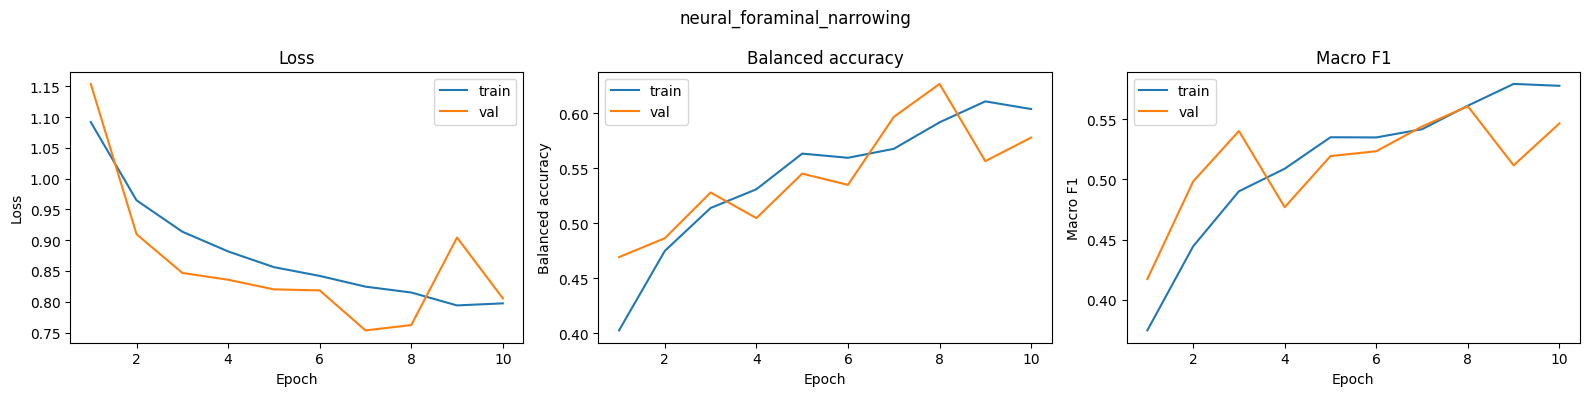


Training model: subarticular_stenosis
Class counts: {'Normal/Mild': np.int64(9601), 'Moderate': np.int64(2549), 'Severe': np.int64(1291)}
Class weights: {'Normal/Mild': np.float32(0.4667), 'Moderate': np.float32(1.7577), 'Severe': np.float32(3.4704)}

Epoch 1/10


  0%|          | 0/840 [00:00<?, ?it/s]

  0%|          | 0/180 [00:00<?, ?it/s]

Train loss: 0.8771 | Train acc: 0.6539 | Train bal acc: 0.5571 | Train macro F1: 0.5245
Val loss: 0.8336 | Val acc: 0.7497 | Val bal acc: 0.6099 | Val macro F1: 0.6131 | Val severe recall: 0.4635
Saved best model: models/models_baseline_three_class_medical/subarticular_stenosis_best.pt

Epoch 2/10


  0%|          | 0/840 [00:00<?, ?it/s]

...

  0%|          | 0/180 [00:00<?, ?it/s]

Train loss: 0.6361 | Train acc: 0.7676 | Train bal acc: 0.7128 | Train macro F1: 0.6835
Val loss: 0.6827 | Val acc: 0.7618 | Val bal acc: 0.6905 | Val macro F1: 0.6641 | Val severe recall: 0.6241

Epoch 10/10


  0%|          | 0/840 [00:00<?, ?it/s]

  0%|          | 0/180 [00:00<?, ?it/s]

Train loss: 0.6284 | Train acc: 0.7717 | Train bal acc: 0.7262 | Train macro F1: 0.6921
Val loss: 0.6494 | Val acc: 0.6974 | Val bal acc: 0.7001 | Val macro F1: 0.6258 | Val severe recall: 0.7774


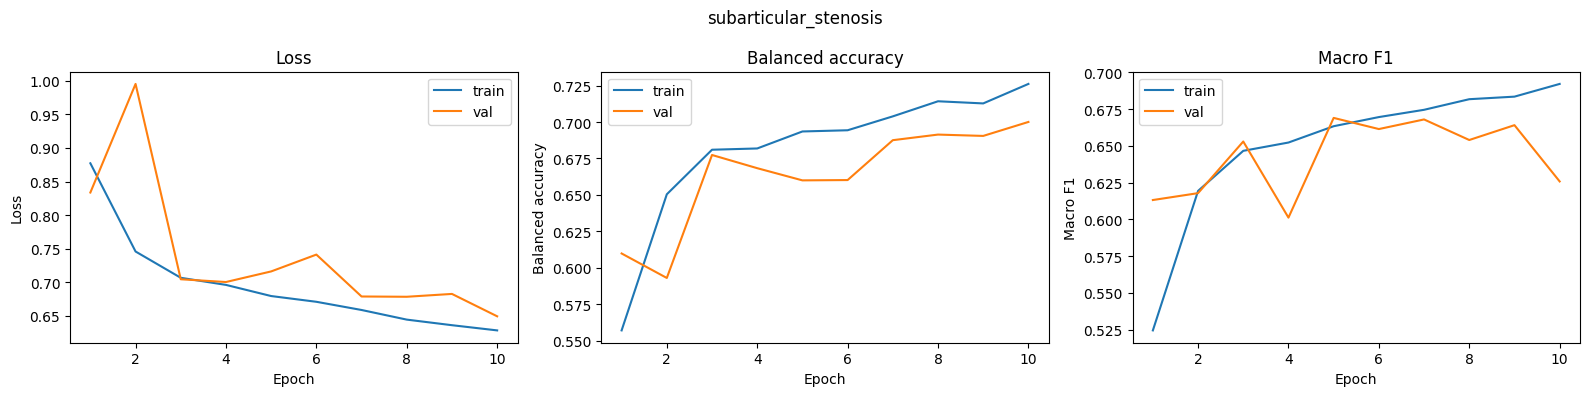

In [19]:
import gc

trained_models = {}
histories = {}

for model_name in MODEL_CONFIGS.keys():
    print("\n" + "=" * 80)
    print(f"Training model: {model_name}")
    print("=" * 80)

    # Avoid stale DataLoader workers when re-running this cell in a notebook.
    try:
        del train_loader
        del val_loader
    except NameError:
        pass
    gc.collect()

    train_part = model_dfs[model_name]["train"]
    val_part = model_dfs[model_name]["val"]

    if len(train_part) == 0 or len(val_part) == 0:
        print(f"Skipping {model_name}: empty train or validation set.")
        continue

    train_loader, val_loader = make_loaders(
        train_part,
        val_part,
        batch_size=BATCH_SIZE,
    )

    model = ResNet34MetadataClassifier(
        n_levels=len(LEVEL_TO_ID),
        n_sides=len(SIDE_TO_ID),
        n_series=len(SERIES_TO_ID),
        n_classes=3,
        pretrained=PRETRAINED,
    ).to(DEVICE)

    criterion = make_class_weighted_loss(train_part, DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
    )

    model, history_df = fit_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=DEVICE,
        epochs=EPOCHS,
    )

    trained_models[model_name] = model
    histories[model_name] = history_df

    plot_history(history_df, title=model_name)


## 15. Test evaluation


Testing model: spinal_canal_stenosis
Class counts: {'Normal/Mild': np.int64(5964), 'Moderate': np.int64(513), 'Severe': np.int64(343)}
Class weights: {'Normal/Mild': np.float32(0.3812), 'Moderate': np.float32(4.4314), 'Severe': np.float32(6.6278)}


  0%|          | 0/92 [00:00<?, ?it/s]

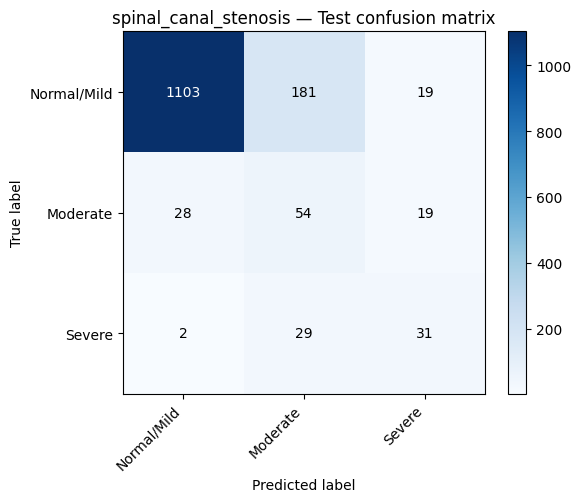

              precision    recall  f1-score   support

 Normal/Mild       0.97      0.85      0.91      1303
    Moderate       0.20      0.53      0.30       101
      Severe       0.45      0.50      0.47        62

    accuracy                           0.81      1466
   macro avg       0.54      0.63      0.56      1466
weighted avg       0.90      0.81      0.85      1466


Testing model: neural_foraminal_narrowing
Class counts: {'Normal/Mild': np.int64(10800), 'Moderate': np.int64(2462), 'Severe': np.int64(517)}
Class weights: {'Normal/Mild': np.float32(0.4253), 'Moderate': np.float32(1.8656), 'Severe': np.float32(8.8839)}


  0%|          | 0/185 [00:00<?, ?it/s]

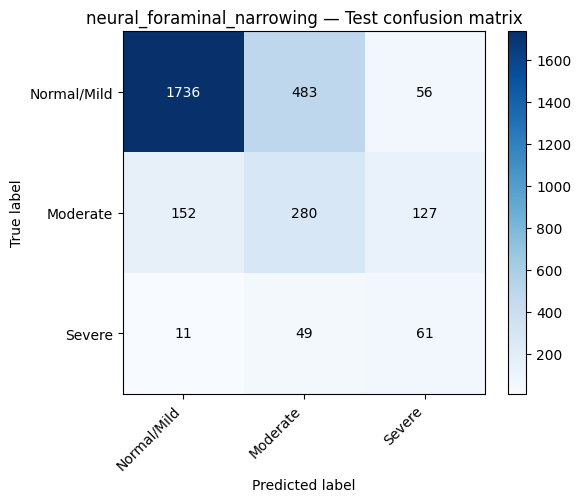

              precision    recall  f1-score   support

 Normal/Mild       0.91      0.76      0.83      2275
    Moderate       0.34      0.50      0.41       559
      Severe       0.25      0.50      0.33       121

    accuracy                           0.70      2955
   macro avg       0.50      0.59      0.52      2955
weighted avg       0.78      0.70      0.73      2955


Testing model: subarticular_stenosis
Class counts: {'Normal/Mild': np.int64(9601), 'Moderate': np.int64(2549), 'Severe': np.int64(1291)}
Class weights: {'Normal/Mild': np.float32(0.4667), 'Moderate': np.float32(1.7577), 'Severe': np.float32(3.4704)}


  0%|          | 0/182 [00:00<?, ?it/s]

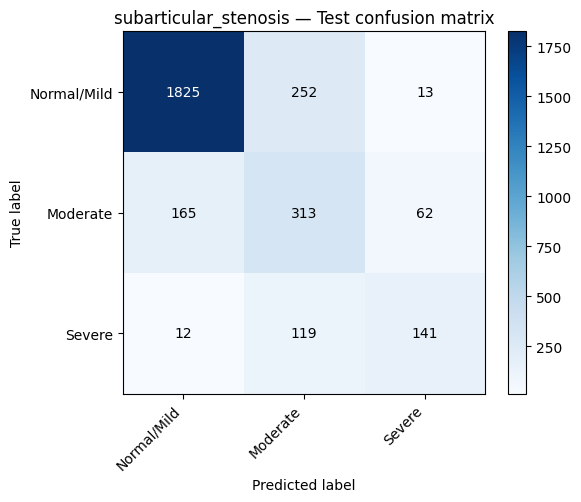

              precision    recall  f1-score   support

 Normal/Mild       0.91      0.87      0.89      2090
    Moderate       0.46      0.58      0.51       540
      Severe       0.65      0.52      0.58       272

    accuracy                           0.79      2902
   macro avg       0.67      0.66      0.66      2902
weighted avg       0.80      0.79      0.79      2902



,model,input,pretrained,test_loss,test_log_loss,test_accuracy,test_balanced_accuracy,test_macro_f1,test_severe_recall,n_test_rows,n_test_studies
0,spinal_canal_stenosis,full_image_grayscale_repeated_3ch_plus_metadata,False,0.725433,0.397236,0.810368,0.627054,0.558252,0.500000,1466,297
1,neural_foraminal_narrowing,full_image_grayscale_repeated_3ch_plus_metadata,False,0.847203,0.644635,0.702876,0.589368,0.524841,0.504132,2955,296
2,subarticular_stenosis,full_image_grayscale_repeated_3ch_plus_metadata,False,0.692835,0.478636,0.785320,0.657073,0.660430,0.518382,2902,297


Saved: models/models_baseline_three_class_medical/test_results_scratch.csv


In [20]:
def load_best_model(model_name):
    model = ResNet34MetadataClassifier(
        n_levels=len(LEVEL_TO_ID),
        n_sides=len(SIDE_TO_ID),
        n_series=len(SERIES_TO_ID),
        n_classes=3,
        pretrained=PRETRAINED,
    ).to(DEVICE)

    model_path = OUTPUT_DIR / f"{model_name}_best.pt"
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))

    return model


test_results = []

for model_name in MODEL_CONFIGS.keys():
    print("\n" + "=" * 80)
    print(f"Testing model: {model_name}")
    print("=" * 80)

    test_part = model_dfs[model_name]["test"]

    if len(test_part) == 0:
        print(f"Skipping {model_name}: empty test set.")
        continue

    model = load_best_model(model_name)
    test_loader = make_test_loader(test_part, batch_size=BATCH_SIZE)

    # Use test split for loss weights only to compute a comparable loss.
    # Metrics such as F1, balanced accuracy and log loss are more important.
    criterion = make_class_weighted_loss(model_dfs[model_name]["train"], DEVICE)

    metrics = evaluate_one_epoch(
        model,
        test_loader,
        criterion,
        DEVICE,
    )

    show_confusion_and_report(
        metrics["y_true"],
        metrics["y_pred"],
        class_names=TARGET_NAMES,
        title=f"{model_name} — Test confusion matrix",
    )

    row = {
        "model": model_name,
        "input": "full_image_grayscale_repeated_3ch_plus_metadata",
        "pretrained": PRETRAINED,
        "test_loss": metrics["loss"],
        "test_log_loss": metrics["log_loss"],
        "test_accuracy": metrics["accuracy"],
        "test_balanced_accuracy": metrics["balanced_accuracy"],
        "test_macro_f1": metrics["macro_f1"],
        "test_severe_recall": metrics["severe_recall"],
        "n_test_rows": len(test_part),
        "n_test_studies": test_part["study_id"].nunique(),
    }

    test_results.append(row)

results_table = pd.DataFrame(test_results)
display(results_table)

suffix = "pretrained" if PRETRAINED else "scratch"
results_path = OUTPUT_DIR / f"test_results_{suffix}.csv"
results_table.to_csv(results_path, index=False)
print("Saved:", results_path)